In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

import seaborn as sns

## Perfectly Linear Dataset

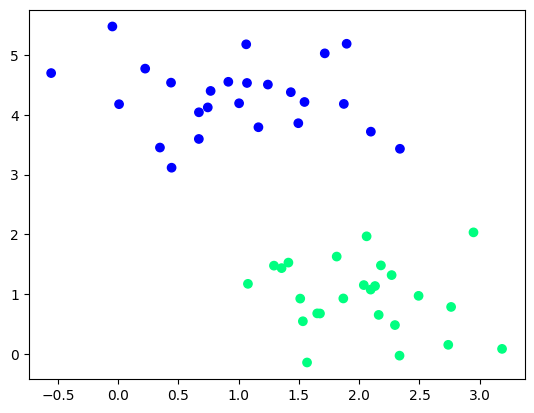

In [4]:
from sklearn.datasets._samples_generator import make_blobs

X , y = make_blobs(n_samples=50, centers = 2, random_state=0, cluster_std=0.60)
plt.scatter(X[:,0], X[:,1], c=y, cmap='winter')

In [5]:
from sklearn.svm import SVC 
model = SVC(kernel='linear', C=1)
model.fit(X, y)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [13]:
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay

def plot_svc_decision_function(model, X, ax=None, plot_support=True):
    """Plot the decision function for a 2D SVC using DecisionBoundaryDisplay."""
    if ax is None:
        ax = plt.gca()

    # 1. Draw boundary and margins
    DecisionBoundaryDisplay.from_estimator(
        model,
        X,
        response_method="decision_function",
        plot_method="contour",
        levels=[-1, 0, 1],
        linestyles=["--", "-", "--"],
        colors="k",
        alpha=0.5,
        ax=ax,
    )

    # 2. Highlight support vectors
    if plot_support and hasattr(model, "support_vectors_"):
        ax.scatter(
            model.support_vectors_[:, 0],
            model.support_vectors_[:, 1],
            s=300,
            linewidth=1.5,
            edgecolors="k",
            facecolors="none",
        )

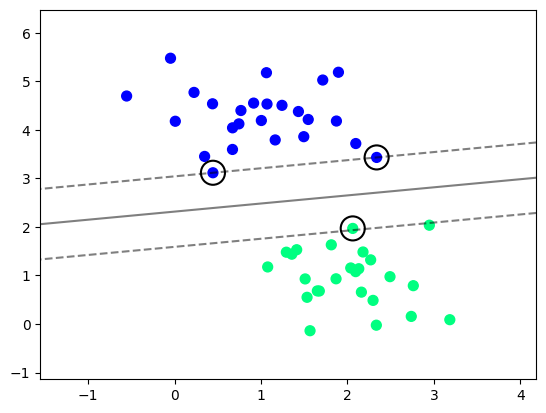

In [14]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap="winter")
plot_svc_decision_function(model, X)
plt.show()

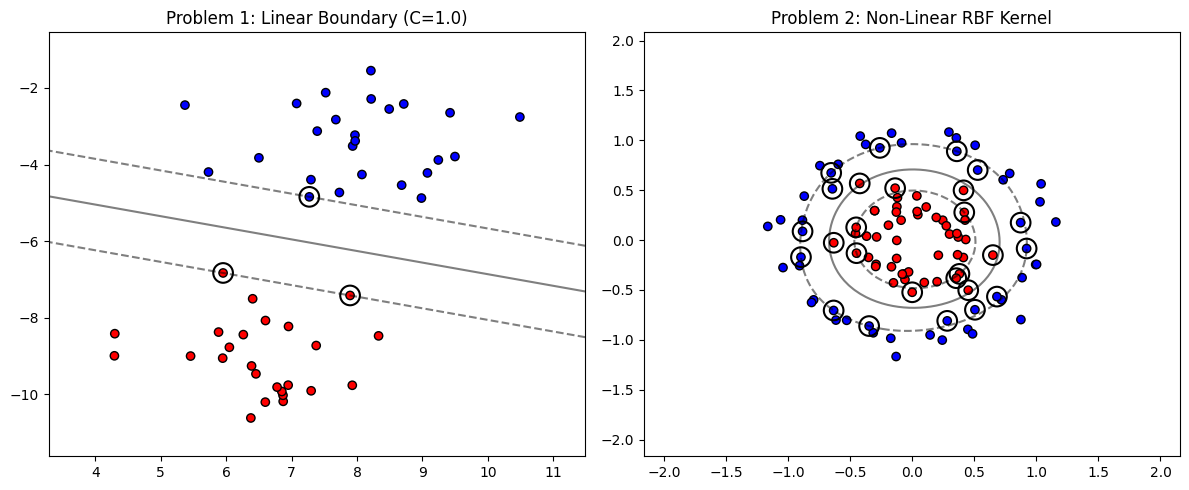

In [28]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_circles
from sklearn.svm import SVC
from sklearn.inspection import DecisionBoundaryDisplay

def plot_svc_decision_function(model, X, ax=None, plot_support=True):
    if ax is None:
        ax = plt.gca()

    DecisionBoundaryDisplay.from_estimator(
        model,
        X,
        response_method="decision_function",
        plot_method="contour",
        levels=[-1, 0, 1],
        linestyles=["--", "-", "--"],
        colors="k",
        alpha=0.5,
        ax=ax,
    )

    if plot_support and hasattr(model, "support_vectors_"):
        ax.scatter(
            model.support_vectors_[:, 0],
            model.support_vectors_[:, 1],
            s=200,
            linewidth=1.5,
            edgecolors="k",
            facecolors="none",
        )

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Problem 1: Linear Kernel (Effect of Margin Regulation 'C')
X_blobs, y_blobs = make_blobs(n_samples=50, centers=2, random_state=6)
linear_svc = SVC(kernel="linear", C=1.0).fit(X_blobs, y_blobs)

axes[0].scatter(X_blobs[:, 0], X_blobs[:, 1], c=y_blobs, cmap="bwr", edgecolors="k")
plot_svc_decision_function(linear_svc, X_blobs, ax=axes[0])
axes[0].set_title("Problem 1: Linear Boundary (C=1.0)")

# Problem 2: RBF Kernel (Non-linear decision surfaces)
X_circ, y_circ = make_circles(n_samples=100, factor=0.4, noise=0.1, random_state=42)
rbf_svc = SVC(kernel="rbf", C=1.0, gamma="scale").fit(X_circ, y_circ)

axes[1].scatter(X_circ[:, 0], X_circ[:, 1], c=y_circ, cmap="bwr", edgecolors="k")
plot_svc_decision_function(rbf_svc, X_circ, ax=axes[1])
axes[1].set_title("Problem 2: Non-Linear RBF Kernel")

plt.tight_layout()
plt.show()